# **The Statistical Home Advantage: How NBA Performance Shifts Between Home and Away Games**

### **DATA102 Machine Project, Phase 1**

*Authors:*
- *GONZALES, Joshua Nicolai*
- *IRLANDEZ, Eara Maxine*
- *REYES, Nathaniel Kurt*
- *SANTOS, Stefanio Nicholas*
- *VELASQUEZ, Gerardo Miguel*

---

This project investigates whether NBA teams show statistically significant differences in performance when playing at home versus away. Rather than assuming that a home-court advantage exists, we use exploratory data analysis and statistical inference to determine which specific game metrics meaningfully change based on venue, and how strongly home location is associated with winning.

This notebook covers the five Phase 1 sections required by the project specifications:
1. **Dataset Description**
2. **Data Cleaning**
3. **Exploratory Data Analysis (EDA)**
4. **Research Question**
5. **Statistical Inference**


---

## **1.0 Dataset Description**

### **Short Description**

This dataset contains detailed information about every NBA game played from the **2004 season up to the 2022 season**. The analysis uses two (2) related files:

- `games.csv`, One row per NBA game, containing team-level box-score statistics for both the home and away teams (points, shooting percentages, assists, rebounds) along with the final outcome.
- `games_details.csv`, One row per player per game, containing each player's individual box-score statistics for every game in the same period.

The two files are linked by a shared `GAME_ID`, which lets us aggregate player-level statistics up to the team level when needed.

### **Dataset Collection Method**

The dataset was obtained from Kaggle (*NBA Games* by Nathan Lauga, [https://www.kaggle.com/datasets/nathanlauga/nba-games](https://www.kaggle.com/datasets/nathanlauga/nba-games)). The uploader compiled it by scraping the **official NBA statistics website** ([https://www.nba.com/stats](https://www.nba.com/stats)), which is the league's authoritative source for box-score data.

### **Implications of the Data Collection Method on this Project's Insights**

- Teams are not *randomly assigned* to play at home or away, the schedule is fixed in advance. This means we can establish whether home and away performance are **associated**, but we cannot prove that the venue itself *causes* the difference. Factors such as travel fatigue, rest days, crowd noise, and referee tendencies cannot be fully isolated.
- The dataset covers essentially every regular-season and playoff game in the period rather than a random sample, so our conclusions describe the NBA over 2004-2022 directly. They may not generalize perfectly to future seasons if the game changes (e.g., rule changes affecting officiating or pace).
- Games played in the 2020 NBA bubble were held at a single neutral site with no true home crowd, which would distort any home-advantage analysis. These games are removed during data cleaning (see Section 2).
- Free-throw attempts (FTA) are not provided at the team level in `games.csv`, so they must be aggregated from the player-level file. Any player-game rows missing from `games_details.csv` would slightly affect those team totals.

### **Structure of the Data**

* **Format:** Tabular data spread across two linked CSV files.
* **Unit of analysis (`games.csv`):** each row is a single NBA game, holding both teams' statistics side by side (`_home` and `_away` columns).
* **Unit of analysis (`games_details.csv`):** each row is a single player's performance in a single game.
* **Number of observations:** the exact counts are confirmed programmatically using `.shape` and `.info()` in Section 1.2 below.

#### **Description of Variables, `games.csv` (Game-Level)**

| **Variable** | **Description** |
|--------------|-----------------|
| GAME_DATE_EST | Date the game was played (Eastern Standard Time) |
| GAME_ID | Unique numeric identifier for each game |
| GAME_STATUS_TEXT | Status of the game (e.g., "Final", "Scheduled") |
| HOME_TEAM_ID | Unique identifier for the home team |
| VISITOR_TEAM_ID | Unique identifier for the visiting (away) team |
| SEASON | NBA season year (e.g., 2016 = 2016-2017 season) |
| TEAM_ID_home | Home team ID (duplicate of HOME_TEAM_ID) |
| PTS_home | Total points scored by the home team |
| FG_PCT_home | Field goal percentage for the home team |
| FT_PCT_home | Free throw percentage for the home team |
| FG3_PCT_home | Three-point percentage for the home team |
| AST_home | Total assists by the home team |
| REB_home | Total rebounds by the home team |
| TEAM_ID_away | Away team ID (duplicate of VISITOR_TEAM_ID) |
| PTS_away | Total points scored by the away team |
| FG_PCT_away | Field goal percentage for the away team |
| FT_PCT_away | Free throw percentage for the away team |
| FG3_PCT_away | Three-point percentage for the away team |
| AST_away | Total assists by the away team |
| REB_away | Total rebounds by the away team |
| HOME_TEAM_WINS | Binary outcome (1 = home team won, 0 = away team won) |

#### **Description of Variables, `games_details.csv` (Player-Level)**

| **Variable** | **Description** |
|--------------|-----------------|
| GAME_ID | Identifier linking back to `games.csv` |
| TEAM_ID | Identifier for the player's team |
| TEAM_ABBREVIATION | 3-letter team code (e.g., LAL, GSW, BOS) |
| TEAM_CITY | City of the team |
| PLAYER_ID | Unique identifier for each player |
| PLAYER_NAME | Full name of the player |
| NICKNAME | Player's nickname (if available) |
| START_POSITION | Starting position (G/F/C; empty = bench) |
| COMMENT | Notes, e.g. reason a player did not play |
| MIN | Minutes played ("MM:SS") |
| FGM / FGA / FG_PCT | Field goals made / attempted / percentage |
| FG3M / FG3A / FG3_PCT | Three-pointers made / attempted / percentage |
| FTM / FTA / FT_PCT | Free throws made / attempted / percentage |
| OREB / DREB / REB | Offensive / defensive / total rebounds |
| AST | Assists |
| STL | Steals |
| BLK | Blocks |
| TO | Turnovers |
| PF | Personal fouls |
| PTS | Total points scored |
| PLUS_MINUS | Team point differential while the player is on court |

---

### **1.1 Importing Libraries**

We first import the libraries needed to manipulate, analyze, and visualize the data throughout this notebook:

- **pandas** (`pd`), flexible DataFrame structures for cleaning, exploring, and manipulating tabular data.
- **numpy** (`np`), fast numerical operations and array math.
- **matplotlib.pyplot** (`plt`), core plotting library for charts.
- **seaborn** (`sns`), higher-level statistical visualization built on matplotlib (boxplots, heatmaps).
- **scipy.stats** (`stats`), statistical-inference functions used later for hypothesis testing.

In [1]:
# Import the necessary libraries.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

We also define two consistent colors used across the charts so that **home** results are always shown in green and **away** results in red.

In [2]:
# Setup the two colors used in bar charts to be uniform.
green = '#2E8B57'
red = '#CD5C5C'

### **1.2 Reading the Dataset**

Load both CSV files into pandas DataFrames with `read_csv()`.

In [3]:
# Turn csv files to data frames.
df_games = pd.read_csv('./Unclean Data/games.csv')
df_games_details = pd.read_csv('./Unclean Data/games_details.csv')

C:\Users\Miguel Velasquez\AppData\Local\Temp\ipykernel_28248\777480470.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_games_details = pd.read_csv('./Unclean Data/games_details.csv')


Use `info()` to verify that the columns described above match the actual loaded structure, including data types and non-null counts.

In [4]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26651 entries, 0 to 26650
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GAME_DATE_EST     26651 non-null  object 
 1   GAME_ID           26651 non-null  int64  
 2   GAME_STATUS_TEXT  26651 non-null  object 
 3   HOME_TEAM_ID      26651 non-null  int64  
 4   VISITOR_TEAM_ID   26651 non-null  int64  
 5   SEASON            26651 non-null  int64  
 6   TEAM_ID_home      26651 non-null  int64  
 7   PTS_home          26552 non-null  float64
 8   FG_PCT_home       26552 non-null  float64
 9   FT_PCT_home       26552 non-null  float64
 10  FG3_PCT_home      26552 non-null  float64
 11  AST_home          26552 non-null  float64
 12  REB_home          26552 non-null  float64
 13  TEAM_ID_away      26651 non-null  int64  
 14  PTS_away          26552 non-null  float64
 15  FG_PCT_away       26552 non-null  float64
 16  FT_PCT_away       26552 non-null  float6

In [5]:
df_games_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668628 entries, 0 to 668627
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   GAME_ID            668628 non-null  int64  
 1   TEAM_ID            668628 non-null  int64  
 2   TEAM_ABBREVIATION  668628 non-null  object 
 3   TEAM_CITY          668628 non-null  object 
 4   PLAYER_ID          668628 non-null  int64  
 5   PLAYER_NAME        668628 non-null  object 
 6   NICKNAME           53037 non-null   object 
 7   START_POSITION     255765 non-null  object 
 8   COMMENT            109689 non-null  object 
 9   MIN                558938 non-null  object 
 10  FGM                558938 non-null  float64
 11  FGA                558938 non-null  float64
 12  FG_PCT             558938 non-null  float64
 13  FG3M               558938 non-null  float64
 14  FG3A               558938 non-null  float64
 15  FG3_PCT            558938 non-null  float64
 16  FT

We confirm the number of observations and variables in each file using `shape` (printed within the `info()` output above), then preview the first few rows with `head()`.

In [6]:
df_games.head(3)

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1


In [7]:
df_games_details.head(3)

,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,...,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
0,22200477,1610612759,SAS,San Antonio,1629641,Romeo Langford,Romeo,F,NaN,18:06,...,1.0,1.0,2.0,0.0,1.0,0.0,2.0,5.0,2.0,-2.0
1,22200477,1610612759,SAS,San Antonio,1631110,Jeremy Sochan,Jeremy,F,NaN,31:01,...,6.0,3.0,9.0,6.0,1.0,0.0,2.0,1.0,23.0,-14.0
2,22200477,1610612759,SAS,San Antonio,1627751,Jakob Poeltl,Jakob,C,NaN,21:42,...,1.0,3.0,4.0,1.0,1.0,0.0,2.0,4.0,13.0,-4.0


---

## **2.0 Data Cleaning**

Before exploration and analysis, we clean and preprocess the data so that discrepancies do not distort our results. Following the project specifications, we check each **used** variable for the following issues and apply cleaning where needed:

- Removing unnecessary variables
- Filtering out non-representative games (the 2020 bubble)
- Missing data
- Incorrect data types
- Multiple representations of the same categorical value
- Duplicate data
- Inconsistent formatting / default values
- Feature engineering (deriving the variables our study requires)

### **2.1 Removing Unnecessary Variables**

We drop columns that are not relevant to a home-court analysis (`GAME_STATUS_TEXT`), and the redundant duplicate ID columns (`TEAM_ID_home`, `TEAM_ID_away`, which simply repeat `HOME_TEAM_ID` and `VISITOR_TEAM_ID`). From the player file we drop descriptive columns we will not analyze (`NICKNAME`, `START_POSITION`, `TEAM_CITY`, `COMMENT`, `MIN`).

In [8]:
# For df_games
# This column is not relevant to the EDA.
df_games = df_games.drop(columns=['GAME_STATUS_TEXT'])

# Duplicate columns
df_games = df_games.drop(columns=['TEAM_ID_home', 'TEAM_ID_away'])

# For df_games_details
# These columns are not relevant to the EDA.
df_games_details = df_games_details.drop(columns=['NICKNAME', 'START_POSITION', 'TEAM_CITY', 'COMMENT', 'MIN'])


cols1 = list(df_games.columns)
cols2 = list(df_games_details.columns)

print("df_games:", cols1)
print("\ndf_games_details:", cols2)

df_games: ['GAME_DATE_EST', 'GAME_ID', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'SEASON', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'HOME_TEAM_WINS']

df_games_details: ['GAME_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'PLAYER_ID', 'PLAYER_NAME', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'PTS', 'PLUS_MINUS']


### **2.2 Filtering Out the 2020 NBA Bubble**

As noted in the dataset implications, games played from **July-October 2020** were held inside the NBA "bubble", a single neutral-site venue with no home crowd. Because these games have no genuine home team, they would contaminate a home-advantage study, so we remove them. We first convert the date column to `datetime`, identify the game IDs to keep, and filter both DataFrames consistently.

In [9]:
# First make sure both dataframes have datetime columns
df_games['GAME_DATE_EST'] = pd.to_datetime(df_games['GAME_DATE_EST'])

# Filter df_games first to get the GAME_IDs to keep
games_to_keep = df_games[
    ~((df_games['GAME_DATE_EST'] >= '2020-07-01') & 
      (df_games['GAME_DATE_EST'] <= '2020-10-31'))
]['GAME_ID']

# Now filter df_games_details based on GAME_IDs to keep
df_games_details_filtered = df_games_details[
    df_games_details['GAME_ID'].isin(games_to_keep)
]

### **2.3 Handling Missing Data**

We check both DataFrames for null values to assess data quality and decide how to handle them.

In [10]:
# Null values in this case can be dropped.
df_games.isna().sum()

GAME_DATE_EST       0
GAME_ID             0
HOME_TEAM_ID        0
VISITOR_TEAM_ID     0
SEASON              0
PTS_home           99
FG_PCT_home        99
FT_PCT_home        99
FG3_PCT_home       99
AST_home           99
REB_home           99
PTS_away           99
FG_PCT_away        99
FT_PCT_away        99
FG3_PCT_away       99
AST_away           99
REB_away           99
HOME_TEAM_WINS      0
dtype: int64

For `df_games`, null rows correspond to games that had not been played yet (no recorded box score), so they carry no usable information and are dropped.

In [11]:
# Drop null values.
df_games = df_games.dropna()

# Double check if null values have been successfully dropped.
df_games.isna().sum()

GAME_DATE_EST      0
GAME_ID            0
HOME_TEAM_ID       0
VISITOR_TEAM_ID    0
SEASON             0
PTS_home           0
FG_PCT_home        0
FT_PCT_home        0
FG3_PCT_home       0
AST_home           0
REB_home           0
PTS_away           0
FG_PCT_away        0
FT_PCT_away        0
FG3_PCT_away       0
AST_away           0
REB_away           0
HOME_TEAM_WINS     0
dtype: int64

We then check the player-level file for nulls.

In [12]:
# Null values means the player didn't play in that game.
df_games_details.isna().sum()

GAME_ID                   0
TEAM_ID                   0
TEAM_ABBREVIATION         0
PLAYER_ID                 0
PLAYER_NAME               0
FGM                  109690
FGA                  109690
FG_PCT               109690
FG3M                 109690
FG3A                 109690
FG3_PCT              109690
FTM                  109690
FTA                  109690
FT_PCT               109690
OREB                 109690
DREB                 109690
REB                  109690
AST                  109690
STL                  109690
BLK                  109690
TO                   109690
PF                   109690
PTS                  109690
PLUS_MINUS           133351
dtype: int64

For `df_games_details`, a null value indicates a player who did not play in that game (no recorded statistics). These rows are likewise dropped, since they contribute nothing to per-game performance.

In [13]:
# Drop null values.
df_games_details = df_games_details.dropna()

# Double check if null values have been successfully dropped.
df_games_details.isna().sum()

GAME_ID              0
TEAM_ID              0
TEAM_ABBREVIATION    0
PLAYER_ID            0
PLAYER_NAME          0
FGM                  0
FGA                  0
FG_PCT               0
FG3M                 0
FG3A                 0
FG3_PCT              0
FTM                  0
FTA                  0
FT_PCT               0
OREB                 0
DREB                 0
REB                  0
AST                  0
STL                  0
BLK                  0
TO                   0
PF                   0
PTS                  0
PLUS_MINUS           0
dtype: int64

### **2.4 Handling Incorrect Data Types**

Next we inspect the data types of each column to confirm they are appropriate for analysis.

In [14]:
# Check data types.
df_games.dtypes

GAME_DATE_EST      datetime64[ns]
GAME_ID                     int64
HOME_TEAM_ID                int64
VISITOR_TEAM_ID             int64
SEASON                      int64
PTS_home                  float64
FG_PCT_home               float64
FT_PCT_home               float64
FG3_PCT_home              float64
AST_home                  float64
REB_home                  float64
PTS_away                  float64
FG_PCT_away               float64
FT_PCT_away               float64
FG3_PCT_away              float64
AST_away                  float64
REB_away                  float64
HOME_TEAM_WINS              int64
dtype: object

Only `GAME_DATE_EST` had an `object` type. We convert it to `datetime64` so we can use date accessors such as `dt.month` and `dt.year` for filtering.

In [15]:
# Change object data types to a more specific data type.
# In this case only GAME_DATE_EST had an object data type.
df_games['GAME_DATE_EST'] = pd.to_datetime(df_games['GAME_DATE_EST'])
df_games.dtypes

GAME_DATE_EST      datetime64[ns]
GAME_ID                     int64
HOME_TEAM_ID                int64
VISITOR_TEAM_ID             int64
SEASON                      int64
PTS_home                  float64
FG_PCT_home               float64
FT_PCT_home               float64
FG3_PCT_home              float64
AST_home                  float64
REB_home                  float64
PTS_away                  float64
FG_PCT_away               float64
FT_PCT_away               float64
FG3_PCT_away              float64
AST_away                  float64
REB_away                  float64
HOME_TEAM_WINS              int64
dtype: object

Checking the player file's data types: only `PLAYER_NAME` and `TEAM_ABBREVIATION` are `object` types (text). We explicitly cast them to string to keep the schema clean. (In pandas, strings are stored under the `object` dtype.)

In [16]:
# Check data types.
df_games_details.dtypes

GAME_ID                int64
TEAM_ID                int64
TEAM_ABBREVIATION     object
PLAYER_ID              int64
PLAYER_NAME           object
FGM                  float64
FGA                  float64
FG_PCT               float64
FG3M                 float64
FG3A                 float64
FG3_PCT              float64
FTM                  float64
FTA                  float64
FT_PCT               float64
OREB                 float64
DREB                 float64
REB                  float64
AST                  float64
STL                  float64
BLK                  float64
TO                   float64
PF                   float64
PTS                  float64
PLUS_MINUS           float64
dtype: object

In [17]:
# Change object data types to a more specific data type.
# Strings are still classified as objects in pandas.
df_games_details['TEAM_ABBREVIATION'] = df_games_details['TEAM_ABBREVIATION'].astype(str)
df_games_details['PLAYER_NAME'] = df_games_details['PLAYER_NAME'].astype(str)
df_games_details.dtypes

GAME_ID                int64
TEAM_ID                int64
TEAM_ABBREVIATION     object
PLAYER_ID              int64
PLAYER_NAME           object
FGM                  float64
FGA                  float64
FG_PCT               float64
FG3M                 float64
FG3A                 float64
FG3_PCT              float64
FTM                  float64
FTA                  float64
FT_PCT               float64
OREB                 float64
DREB                 float64
REB                  float64
AST                  float64
STL                  float64
BLK                  float64
TO                   float64
PF                   float64
PTS                  float64
PLUS_MINUS           float64
dtype: object

### **2.5 Checking for Multiple Representations and Inconsistent Formatting**

Because most of our analytical variables are **numeric box-score statistics**, the main categorical field at risk of multiple representations is the team identifier. We verify that team abbreviations are consistently formatted (a fixed set of 3-letter codes) and that the binary outcome column `HOME_TEAM_WINS` contains only the two expected values, 0 and 1.

In [18]:
# Categorical variables most at risk of inconsistent representation are the
# team abbreviations and the binary win flag. We confirm they are clean.

print("Unique HOME_TEAM_WINS values:", sorted(df_games['HOME_TEAM_WINS'].unique()))
print("Number of unique player-file team abbreviations:", df_games_details['TEAM_ABBREVIATION'].nunique())
print("\nSample team abbreviations:", sorted(df_games_details['TEAM_ABBREVIATION'].unique())[:10])


Unique HOME_TEAM_WINS values: [np.int64(0), np.int64(1)]
Number of unique player-file team abbreviations: 34

Sample team abbreviations: ['ATL', 'BKN', 'BOS', 'CHA', 'CHI', 'CLE', 'DAL', 'DEN', 'DET', 'GSW']


The win flag contains only `0` and `1`, which is correct. However, there are **34 unique team abbreviations** when the NBA has only **30 teams**. This is a genuine multiple-representation issue: four extra codes exist because several franchises **relocated or rebranded** during the 2004-2022 period, so the same franchise appears under different abbreviations in different seasons:

- `NJN` (New Jersey Nets) > `BKN` (Brooklyn Nets, from 2012)
- `SEA` (Seattle SuperSonics) > `OKC` (Oklahoma City Thunder, from 2008)
- `NOH` (New Orleans Hornets) and `NOK` (New Orleans/Oklahoma City Hornets, the 2005-2007 displacement seasons) > `NOP` (New Orleans Pelicans, from 2013)

The New Orleans franchise alone accounts for three codes (`NOH`, `NOK`, `NOP`). We normalize each franchise to its current abbreviation below so that per-team aggregations treat each franchise as a single entity.

In [19]:
# Map historical/relocated franchise codes to their current abbreviation
# so that each franchise is represented consistently as one entity.
franchise_map = {
    'NJN': 'BKN', # New Jersey Nets > Brooklyn Nets
    'SEA': 'OKC', # Seattle SuperSonics > Oklahoma City Thunder
    'NOH': 'NOP', # New Orleans Hornets > New Orleans Pelicans
    'NOK': 'NOP', # New Orleans/Oklahoma City Hornets > New Orleans Pelicans
}

# Apply to the player-level file (the source of team abbreviations)
df_games_details['TEAM_ABBREVIATION'] = df_games_details['TEAM_ABBREVIATION'].replace(franchise_map)

# The team-level home/away abbreviation columns are created later (Section 2.7) by
# aggregating from this player file, so they will inherit these normalized codes.

# Verify we now have exactly 30 franchises
print("Unique player-file abbreviations after normalization:",
      df_games_details['TEAM_ABBREVIATION'].nunique())
print(sorted(df_games_details['TEAM_ABBREVIATION'].unique()))


Unique player-file abbreviations after normalization: 30
['ATL', 'BKN', 'BOS', 'CHA', 'CHI', 'CLE', 'DAL', 'DEN', 'DET', 'GSW', 'HOU', 'IND', 'LAC', 'LAL', 'MEM', 'MIA', 'MIL', 'MIN', 'NOP', 'NYK', 'OKC', 'ORL', 'PHI', 'PHX', 'POR', 'SAC', 'SAS', 'TOR', 'UTA', 'WAS']


After normalization the dataset contains exactly **30 unique franchises**, so each team's home and away games are now correctly grouped under a single abbreviation. This matters for the per-team comparison in the EDA, where a relocated franchise would otherwise be split into two separate bars.

### **2.6 Checking for Duplicate Data**

We check for fully duplicated rows, which would double-count games or player performances and bias our averages.

In [20]:
# Check for duplicate games and duplicate player-game records.
print("Duplicate rows in df_games:", df_games.duplicated().any())
print("Duplicate rows in df_games_details:", df_games_details.duplicated().any())


Duplicate rows in df_games: False
Duplicate rows in df_games_details: False


No exact duplicate rows are present in either file, so no de-duplication is required.

### **2.7 Feature Engineering**

Our study requires several variables that are not directly present in `games.csv`. We derive them here.

**(a) Team-level free-throw attempts (FTA).** `games.csv` does not store team FTA, but referee-bias analysis needs it. We aggregate player FTA up to the team level per game from `games_details.csv` using `groupby()` + `sum()`, then merge the home and away totals back into `df_games` as `FTA_home` and `FTA_away`.

In [21]:
# First, aggregate FTA per team per game
team_fta_per_game = df_games_details.groupby(['GAME_ID', 'TEAM_ID', 'TEAM_ABBREVIATION'])['FTA'].sum().reset_index()

# Create separate DataFrames for home and away
home_fta = team_fta_per_game.copy()
away_fta = team_fta_per_game.copy()

# Rename columns appropriately
home_fta.columns = ['GAME_ID', 'HOME_TEAM_ID', 'TEAM_ABBREVIATION_home', 'FTA_home']
away_fta.columns = ['GAME_ID', 'VISITOR_TEAM_ID', 'TEAM_ABBREVIATION_away', 'FTA_away']

# Merge both
df_games = df_games.merge(home_fta, on=['GAME_ID', 'HOME_TEAM_ID'], how='left')
df_games = df_games.merge(away_fta, on=['GAME_ID', 'VISITOR_TEAM_ID'], how='left')
df_games = df_games.dropna()

With cleaning and feature engineering complete, we now have a tidy game-level DataFrame (`df_games`) with paired home/away statistics which will serve as the foundation for the EDA that follows.

---

## **3.0 Exploratory Data Analysis (EDA)**

In this section we explore the cleaned data to understand how performance differs between home and away games. Each EDA question is answered with **both** a numerical summary (means, standard deviations, correlations) **and** an appropriate visualization, accompanied by a written interpretation. The patterns uncovered here directly motivate the research question stated in Section 4.

### **3.1 Reusable Helper Functions**

To keep the analysis consistent and readable, we define a few helper functions used throughout the EDA.

The `create_bar_chart()` function builds a styled vertical bar chart with value labels and optional percentage annotations.

In [22]:
# Simple vertical bar chart with value labels.
def create_bar_chart(data, labels, title, ylabel, value_format='{:.2f}', percentage_annotations=False, total_games=None):
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, data, color=[green, red], edgecolor='black')
    plt.bar_label(bars, fmt=value_format, fontweight='bold')
    if percentage_annotations and total_games:
        pct = [f'{v/total_games*100:.1f}%' for v in data]
        plt.bar_label(bars, labels=pct, label_type='center', color='white', fontweight='bold')
    plt.ylabel(ylabel)
    plt.title(title, fontweight='bold')
    plt.show()


The `create_bar_chart_horizontal()` function builds a horizontal bar chart, which is useful when category labels are long (such as team or player names).

In [23]:
# Simple horizontal bar chart with value labels.
def create_bar_chart_horizontal(data, labels, title, xlabel, colors=None, value_format='{:.2f}'):
    plt.figure(figsize=(10, 7))
    bars = plt.barh(labels, data, color=colors or green, edgecolor='black')
    plt.bar_label(bars, fmt=value_format, fontweight='bold')
    plt.xlabel(xlabel)
    plt.title(title, fontweight='bold')
    plt.show()


The `plot_distribution_of_differences()` function plots a histogram of the per-game **home-minus-away** difference for a chosen statistic, with a dashed line marking the mean difference. This visualizes both the typical home advantage and its game-to-game variability.

In [24]:
# Histogram of the per-game home-minus-away difference for a statistic.
def plot_distribution_of_differences(df, home_col, away_col):
    stat = home_col.split('_')[0]
    diff = df[home_col] - df[away_col]
    plt.figure(figsize=(9, 5))
    plt.hist(diff, bins=50, color=green, edgecolor='black')
    plt.axvline(diff.mean(), color=red, linestyle='--', label=f'Mean: {diff.mean():.2f}')
    plt.xlabel(f'Home minus Away {stat}')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Home {stat} Advantage', fontweight='bold')
    plt.legend()
    plt.show()


The `perform_home_away_test()` function will be used later in the Statistical Inference section. It computes the per-game difference for a statistic, runs a **paired t-test** comparing home versus away, and reports the mean difference, standard deviation, standard error, 95% confidence interval, t-statistic, and p-value.

In [25]:
def perform_home_away_test(df, stat, print_results=True):
    
    # Create column names
    home_col = f"{stat}_home"
    away_col = f"{stat}_away"
    diff_col = f"{stat}_diff"
    
    # Calculate difference
    df[diff_col] = df[home_col] - df[away_col]
    
    # Direct paired test
    t_stat, p_value = stats.ttest_rel(df[home_col], df[away_col])
    
    # Calculate key statistics
    n_games = len(df)
    mean_diff = df[diff_col].mean()
    std_diff = df[diff_col].std()
    se_diff = std_diff / (n_games ** 0.5)
    ci_lower = mean_diff - 1.96 * se_diff
    ci_upper = mean_diff + 1.96 * se_diff
    
    # Print results if requested
    # Default is true
    if print_results:
        # Determine units based on stat
        if stat in ['FG_PCT', 'FT_PCT', 'FG3_PCT']:
            units = "percentage points"
        elif stat == 'PTS':
            units = "points"
        elif stat == 'REB':
            units = "rebounds"
        elif stat == 'AST':
            units = "assists"
        else:
            units = "units"
        
        print(f"Number of games: {n_games}")
        print(f"Mean home advantage: {mean_diff:.2f} {units}")
        print(f"Standard deviation of difference: {std_diff:.2f}")
        print(f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
        print(f"t-statistic: {t_stat:.2f}")
        print(f"p-value: {p_value:.4f}")
        print("\n")
        
        if p_value < 0.05:
            print(f"CONCLUSION: Home and away {stat.lower()} differ significantly (p < 0.05)")
        else:
            print(f"CONCLUSION: No significant difference in {stat.lower()} between home and away (p >= 0.05)")
        print("\n")
    
    # Return results as dictionary
    results = {
        'statistic': stat,
        'n_games': n_games,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'se_diff': se_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        't_stat': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'home_col': home_col,
        'away_col': away_col,
        'diff_col': diff_col
    }
    
    return results

### **EDA Question 1: Do home teams win more often than away teams?**

We begin with the most fundamental indicator of home advantage, the **win rate**. We compute the total number of home wins versus away wins, express them as percentages, and visualize the split.

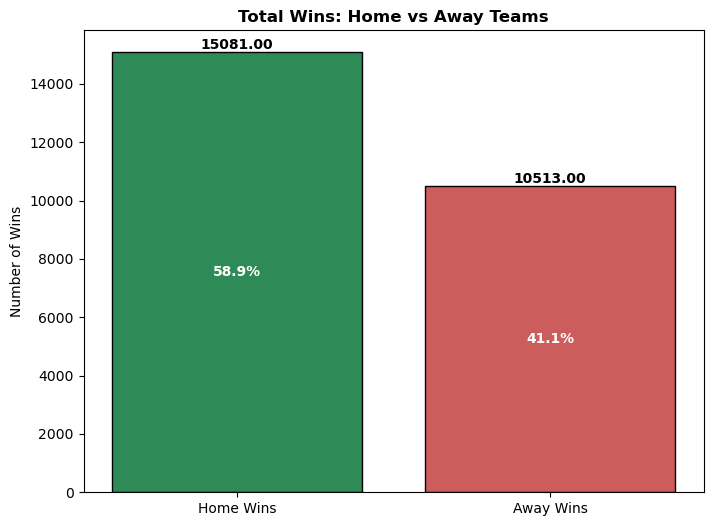

In [26]:
# For wins comparison
home_wins = df_games['HOME_TEAM_WINS'].sum()
away_wins = (df_games['HOME_TEAM_WINS'] == 0).sum()

create_bar_chart(
    data=[home_wins, away_wins],
    labels=['Home Wins', 'Away Wins'],
    title='Total Wins: Home vs Away Teams',
    ylabel='Number of Wins',
    percentage_annotations=True,
    total_games=len(df_games)
)

**Numerical summary:**

In [27]:
# Numerical summary for win rate
home_win_pct = home_wins / len(df_games) * 100
away_win_pct = away_wins / len(df_games) * 100
print(f"Total games: {len(df_games):,}")
print(f"Home wins: {home_wins:,}  ({home_win_pct:.2f}%)")
print(f"Away wins: {away_wins:,}  ({away_win_pct:.2f}%)")
print(f"Home advantage in win rate: {home_win_pct - away_win_pct:.2f} percentage points")


Total games: 25,594
Home wins: 15,081  (58.92%)
Away wins: 10,513  (41.08%)
Home advantage in win rate: 17.85 percentage points


**Interpretation:** Home teams win clearly more often than away teams, roughly **59%** of games versus **41%**. This is the strongest preliminary sign that a home-court advantage exists and frames every question that follows: *if* home teams win more, *which* on-court statistics drive that gap? This finding is formally tested in Section 5.

### **EDA Question 2: Do home teams score more points than away teams?**

A natural first driver to examine is scoring. We look at the distribution of the per-game point difference (home minus away) to see both the typical size of the home scoring advantage and how much it varies from game to game.

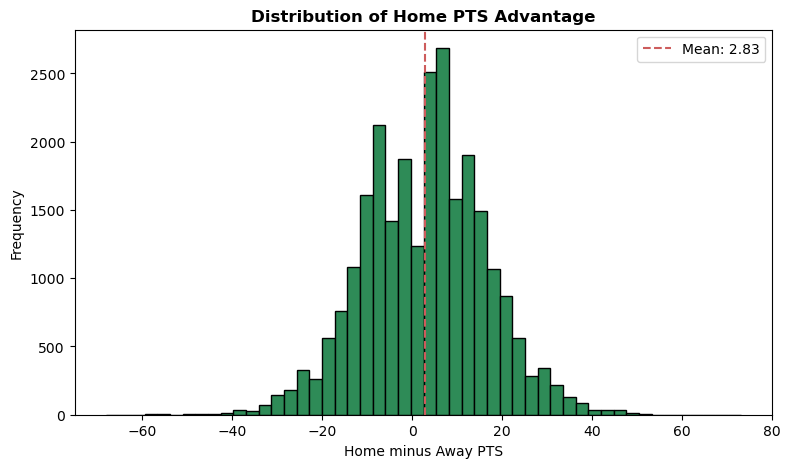

In [28]:
# Difference in points
plot_distribution_of_differences(df_games, 'PTS_home', 'PTS_away')

**Numerical summary of the scoring difference:**

In [29]:
# Numerical summary for points difference
df_games['PTS_diff'] = df_games['PTS_home'] - df_games['PTS_away']
print("Home points , mean: {:.2f}, std: {:.2f}".format(df_games['PTS_home'].mean(), df_games['PTS_home'].std()))
print("Away points , mean: {:.2f}, std: {:.2f}".format(df_games['PTS_away'].mean(), df_games['PTS_away'].std()))
print("Difference  , mean: {:.2f}, median: {:.2f}, std: {:.2f}".format(
    df_games['PTS_diff'].mean(), df_games['PTS_diff'].median(), df_games['PTS_diff'].std()))


Home points , mean: 103.69, std: 13.26
Away points , mean: 100.86, std: 13.43
Difference  , mean: 2.83, median: 4.00, std: 13.52


The mean point difference of roughly **+2.8 points** indicates home teams consistently outscore visitors, though the wide spread shows individual games vary substantially. Next we check whether this advantage is stable across seasons.

The consistent positive point difference of about 2.8 points per game makes scoring a leading candidate for how the win-rate advantage is produced. We test this difference formally in Section 5.


### **EDA Question 3: Do home teams generate more assists and rebounds (game-control metrics)?**

Beyond raw scoring, we examine two "game-control" metrics, assists (playmaking) and rebounds (possession control), to see whether home teams also dominate the supporting statistics.

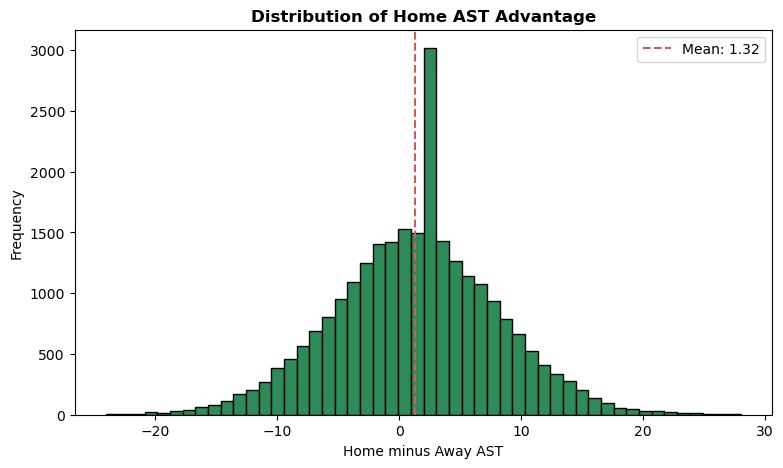

In [30]:
# Difference in assists
plot_distribution_of_differences(df_games, 'AST_home', 'AST_away')

**Numerical summary for assists:**

In [31]:
df_games['AST_diff'] = df_games['AST_home'] - df_games['AST_away']
print("Home assists, mean: {:.2f}, std: {:.2f}".format(df_games['AST_home'].mean(), df_games['AST_home'].std()))
print("Away assists, mean: {:.2f}, std: {:.2f}".format(df_games['AST_away'].mean(), df_games['AST_away'].std()))
print("Assist difference, mean: {:.2f}, std: {:.2f}".format(df_games['AST_diff'].mean(), df_games['AST_diff'].std()))


Home assists, mean: 22.89, std: 5.20
Away assists, mean: 21.56, std: 5.17
Assist difference, mean: 1.32, std: 6.78


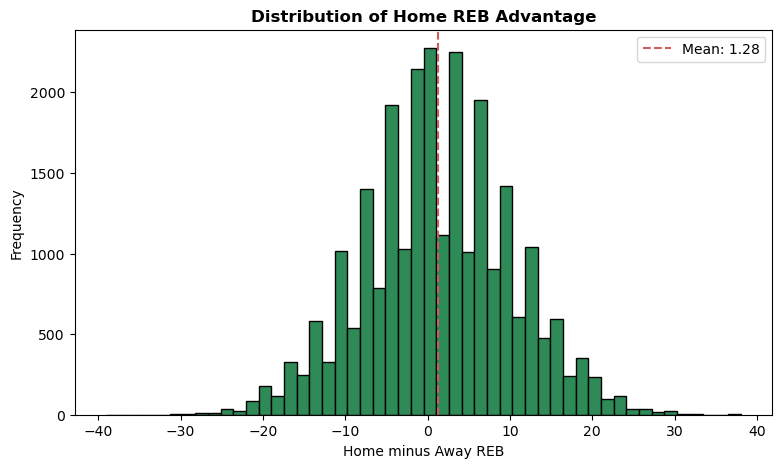

In [32]:
# Difference in rebounds
plot_distribution_of_differences(df_games, 'REB_home', 'REB_away')

**Numerical summary for rebounds:**

In [33]:
df_games['REB_diff'] = df_games['REB_home'] - df_games['REB_away']
print("Home rebounds, mean: {:.2f}, std: {:.2f}".format(df_games['REB_home'].mean(), df_games['REB_home'].std()))
print("Away rebounds, mean: {:.2f}, std: {:.2f}".format(df_games['REB_away'].mean(), df_games['REB_away'].std()))
print("Rebound difference, mean: {:.2f}, std: {:.2f}".format(df_games['REB_diff'].mean(), df_games['REB_diff'].std()))


Home rebounds, mean: 43.42, std: 6.62
Away rebounds, mean: 42.14, std: 6.54
Rebound difference, mean: 1.28, std: 8.99


**Interpretation:** Home teams average roughly **1.3 more assists** and **1.3 more rebounds** per game. Both distributions sit mostly to the positive side of zero, though rebounds vary more game-to-game. Home teams thus hold a modest but consistent edge in both playmaking and possession control.

### **EDA Question 4: Do home teams shoot more efficiently and attempt more free throws?**

Finally, we examine efficiency and officiating-related metrics: field-goal %, three-point %, free-throw %, and free-throw attempts (FTA). FTA is of special interest because of the popular "referee bias" hypothesis, that home teams are awarded more trips to the line.

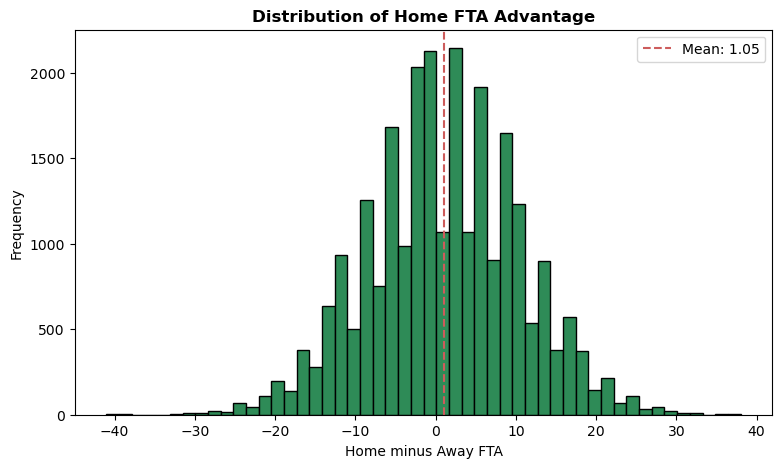

In [34]:
# Difference in fta
plot_distribution_of_differences(df_games, 'FTA_home', 'FTA_away')

**Numerical summary for free-throw attempts:**

In [35]:
df_games['FTA_diff'] = df_games['FTA_home'] - df_games['FTA_away']
print("FTA difference, mean: {:.2f}, std: {:.2f}".format(df_games['FTA_diff'].mean(), df_games['FTA_diff'].std()))


FTA difference, mean: 1.05, std: 9.45


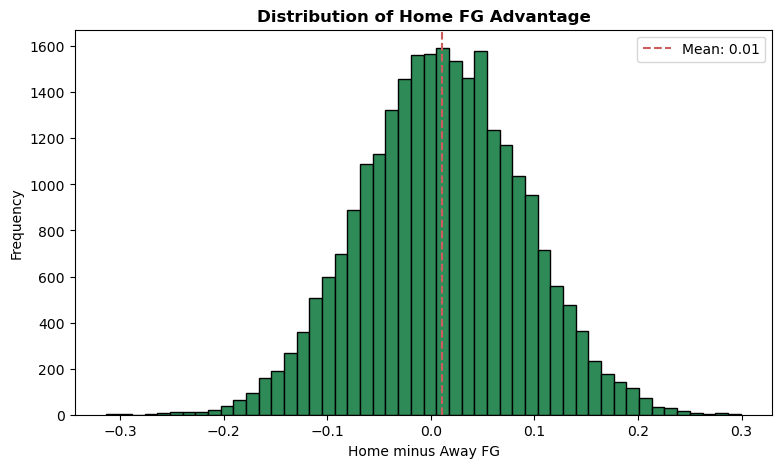

In [36]:
# Difference in fg%
plot_distribution_of_differences(df_games, 'FG_PCT_home', 'FG_PCT_away')

**Numerical summary for field-goal percentage:**

In [37]:
df_games['FG_PCT_diff'] = df_games['FG_PCT_home'] - df_games['FG_PCT_away']
print("FG% difference, mean: {:.4f}, std: {:.4f}".format(df_games['FG_PCT_diff'].mean(), df_games['FG_PCT_diff'].std()))


FG% difference, mean: 0.0109, std: 0.0775


**Numerical summary for free-throw percentage:**

In [38]:
df_games['FT_PCT_diff'] = df_games['FT_PCT_home'] - df_games['FT_PCT_away']
print("FT% difference, mean: {:.4f}, std: {:.4f}".format(df_games['FT_PCT_diff'].mean(), df_games['FT_PCT_diff'].std()))


FT% difference, mean: 0.0016, std: 0.1421


**Numerical summary for three-point percentage:**

In [39]:
df_games['FG3_PCT_diff'] = df_games['FG3_PCT_home'] - df_games['FG3_PCT_away']
print("3P% difference, mean: {:.4f}, std: {:.4f}".format(df_games['FG3_PCT_diff'].mean(), df_games['FG3_PCT_diff'].std()))


3P% difference, mean: 0.0065, std: 0.1552


**Interpretation:** Home teams show a small but positive edge in FG% and 3P%, and attempt about **1 more free throw** per game, consistent with the referee-bias idea. Free-throw *percentage*, however, is essentially tied (the difference clusters tightly around zero): home teams get to the line more, but once there they are no more accurate. This split is an important clue we revisit in the conclusions.

### **EDA Question 5: Which underlying performance differences are most associated with a home win?**

We connect the component statistics back to *winning* by correlating each home-minus-away differential with the binary outcome `HOME_TEAM_WINS`. We deliberately **exclude the point differential**: because a team wins exactly when its points exceed the opponent's, `PTS_diff` is mechanically the same information as the outcome and would produce a meaningless near-perfect correlation. Restricting attention to the component skills (shooting, rebounding, playmaking, free-throw attempts) lets us ask a genuine question: which underlying differences actually move together with winning?

Correlation of each component differential with HOME_TEAM_WINS (PTS excluded):
FG_PCT_diff     0.629
AST_diff        0.457
FG3_PCT_diff    0.421
REB_diff        0.368
FTA_diff        0.192
FT_PCT_diff     0.146
Name: HOME_TEAM_WINS, dtype: float64


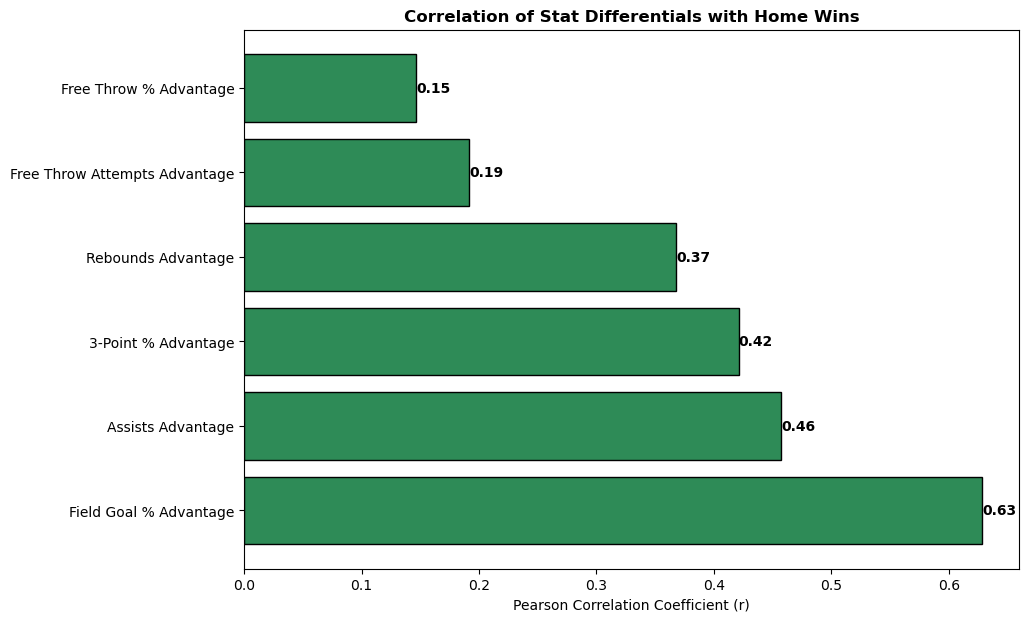

In [55]:
# Correlation between each home-minus-away differential and the home win outcome.
# PTS_diff is deliberately EXCLUDED: a team wins if and only if its point
# differential is positive, so PTS_diff is mechanically equivalent to the
# outcome. We keep only the component skills that influence scoring without determining the result.
component_cols = ['FG_PCT_diff', 'FG3_PCT_diff', 'FT_PCT_diff', 'AST_diff', 'REB_diff', 'FTA_diff']

for stat in ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'AST', 'REB', 'FTA']:
    dc = f'{stat}_diff'
    if dc not in df_games.columns:
        df_games[dc] = df_games[f'{stat}_home'] - df_games[f'{stat}_away']

corr_with_win = df_games[component_cols + ['HOME_TEAM_WINS']].corr()['HOME_TEAM_WINS'].drop('HOME_TEAM_WINS').sort_values(ascending=False)
print("Correlation of each component differential with HOME_TEAM_WINS (PTS excluded):")
print(corr_with_win.round(3))

# Visualizing correlations
label_map = {
    'FG_PCT_diff': 'Field Goal % Advantage',
    'FG3_PCT_diff': '3-Point % Advantage',
    'AST_diff': 'Assists Advantage',
    'REB_diff': 'Rebounds Advantage',
    'FTA_diff': 'Free Throw Attempts Advantage',
    'FT_PCT_diff': 'Free Throw % Advantage'
}

readable_labels = [label_map.get(col, col) for col in corr_with_win.index]

create_bar_chart_horizontal(
    data=corr_with_win.values,
    labels=readable_labels,
    title='Correlation of Stat Differentials with Home Wins',
    xlabel='Pearson Correlation Coefficient (r)',
    colors=green
)


**Interpretation:** Among the component differentials, field-goal percentage and rebounding show the strongest associations with a home win, followed by assists. Free-throw percentage shows the weakest association.

---

## **4.0 Research Question**

The exploratory analysis above established three things: (1) home teams win clearly more often (~59% vs ~41%), (2) they hold consistent positive edges in points, assists, rebounds, shooting efficiency, and free-throw attempts, and (3) those statistical differentials are correlated with winning to differing degrees. These observations lead naturally to one central question:

> ### **Does playing at home significantly raise an NBA team's probability of winning, and which game statistics most account for that advantage?**

### **Connection to the EDA**

This question arises directly from the EDA. Question 1 surfaced the headline win-rate gap; Questions 2-4 identified the candidate statistical channels (scoring, playmaking, rebounding, shooting efficiency, and free-throw attempts); and Question 5 ranked how strongly each differential is associated with winning. The research question ties these threads together by asking not only *whether* home advantage exists, but *which measured factors explain it*.

### **Scope and Answerability**

The question is fully within the scope of the dataset: `HOME_TEAM_WINS` provides the binary outcome, and the cleaned home-minus-away differentials provide the explanatory variables.

### **Significance**

Home-court advantage is one of the most discussed yet often-assumed phenomena in sports in general. Quantifying it matters for several audiences: **coaches and analysts** can prioritize the factors (e.g., rebounding, shot quality) that travel poorly on the road; **fans and commentators** get an evidence-based answer to the "referee bias" debate; and **sports-analytics and betting models** depend on an accurate, well-calibrated estimate of the home effect. Establishing *which* statistics mediate the advantage is more actionable than simply confirming the advantage exists.

---

## **5.0 Statistical Inference**

Having described the patterns visually and numerically, we now formally test whether the observed home advantages are **statistically significant** rather than due to chance. We use a significance level of **α = 0.05** throughout.

We use two complementary tests:
- A **one-sample z-test for a proportion** on the home win rate, to test whether home teams win significantly more than the 50% chance baseline.
- **Paired t-tests** on each team statistic, comparing the home and away values that are naturally paired within the same game.

Because each game contributes one home value and one away value, the home and away observations are *paired*, which is why the paired t-test (rather than an independent two-sample test) is the correct choice for the per-game statistics. With tens of thousands of games, the Central Limit Theorem ensures the sampling distribution of the mean difference is approximately normal, so the t-test is reliable even though individual game statistics are not perfectly normal.

### **5.1 Win Rate, One-Sample Z-Test for a Proportion**

**Hypotheses:**
- H0: the home win probability equals 0.5 (no home advantage).
- H1: the home win probability is greater than 0.5 (home advantage exists).

We compare the observed home win proportion against the 0.5 baseline. The z-test is appropriate here because the outcome is binary (win/loss) and the sample is very large.

In [41]:
# One-proportion z-test: is the home win rate greater than the 0.5 baseline?
from scipy.stats import norm

n_games = len(df_games)
p_hat = home_wins / n_games            # observed home win proportion
p0 = 0.5                               # null baseline (no home advantage)

# z-statistic uses the null standard error sqrt(p0*(1-p0)/n)
z_stat = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n_games)
p_value = 1 - norm.cdf(z_stat)         # one-tailed (H1: p > 0.5)

# 95% confidence interval for the proportion uses the observed standard error
se_hat = np.sqrt(p_hat * (1 - p_hat) / n_games)
ci_lower = p_hat - 1.96 * se_hat
ci_upper = p_hat + 1.96 * se_hat

print(f"Number of games: {n_games}")
print(f"Home win proportion: {p_hat:.4f} ({p_hat:.2%})")
print(f"95% CI for home win proportion: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"z-statistic: {z_stat:.2f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("CONCLUSION: Home teams win significantly more than the 50% baseline (p < 0.05)")
else:
    print("CONCLUSION: No significant home advantage in win rate (p >= 0.05)")


Number of games: 25594
Home win proportion: 0.5892 (58.92%)
95% CI for home win proportion: [0.5832, 0.5953]
z-statistic: 28.55
p-value: 0.0000
CONCLUSION: Home teams win significantly more than the 50% baseline (p < 0.05)


**Result:** The home win rate of ~58.9% is far above 50%, and the one-tailed p-value is effectively **0** (p < 0.05). We **reject H0** and conclude that home teams win significantly more often than chance would predict, confirming the core of the home-court advantage.

### **5.2 Points per Game, Paired T-Test**

**Hypotheses:**
- H0: the mean home and away points per game are equal (mean difference = 0).
- H1: the mean points differ between home and away.

We run the paired t-test using the helper defined earlier.

In [42]:
results_pts = perform_home_away_test(df_games, 'PTS')

Number of games: 25594
Mean home advantage: 2.83 points
Standard deviation of difference: 13.52
95% CI: [2.67, 3.00]
t-statistic: 33.51
p-value: 0.0000


CONCLUSION: Home and away pts differ significantly (p < 0.05)




The difference of ~2.8 points per game is statistically significant (p < 0.05), so we reject H0: home teams score significantly more.

### **5.3 Assists per Game, Paired T-Test**

- H0: mean home assists = mean away assists. 
- H1: they differ.

In [43]:
results_pts = perform_home_away_test(df_games, 'AST')

Number of games: 25594
Mean home advantage: 1.32 assists
Standard deviation of difference: 6.78
95% CI: [1.24, 1.41]
t-statistic: 31.26
p-value: 0.0000


CONCLUSION: Home and away ast differ significantly (p < 0.05)




The ~1.3-assist advantage is significant (p < 0.05); we reject H0.

### **5.4 Rebounds per Game, Paired T-Test**

- H0: mean home rebounds = mean away rebounds. 
- H1: they differ.

In [44]:
results_pts = perform_home_away_test(df_games, 'REB')

Number of games: 25594
Mean home advantage: 1.28 rebounds
Standard deviation of difference: 8.99
95% CI: [1.17, 1.39]
t-statistic: 22.74
p-value: 0.0000


CONCLUSION: Home and away reb differ significantly (p < 0.05)




The ~1.3-rebound advantage is significant (p < 0.05); we reject H0.

### **5.5 Free-Throw Attempts, Paired T-Test**

- H0: mean home FTA = mean away FTA. 
- H1: they differ. This directly tests the "referee bias" hypothesis.

In [45]:
results_pts = perform_home_away_test(df_games, 'FTA')

Number of games: 25594
Mean home advantage: 1.05 units
Standard deviation of difference: 9.45
95% CI: [0.93, 1.16]
t-statistic: 17.70
p-value: 0.0000


CONCLUSION: Home and away fta differ significantly (p < 0.05)




Home teams attempt significantly more free throws (~1 more per game, p < 0.05); we reject H0, consistent with the referee-bias idea.

### **5.6 Field-Goal Percentage, Paired T-Test**

- H0: mean home FG% = mean away FG%. 
- H1: they differ.

In [ ]:
results_pts = perform_home_away_test(df_games, 'FG_PCT')

Number of games: 25594
Mean home advantage: 0.01 percentage points
Standard deviation of difference: 0.08
95% CI: [0.01, 0.01]
t-statistic: 22.59
p-value: 0.0000


CONCLUSION: Home and away fg_pct differ significantly (p < 0.05)




The shooting-efficiency edge is small but statistically significant (p < 0.05); we reject H0.

### **5.7 Free-Throw Percentage, Paired T-Test**

- H0: mean home FT% = mean away FT%.
- H1: they differ. This is the key contrast to FTA.

In [ ]:
results_ft_pct = perform_home_away_test(df_games, 'FT_PCT')

Number of games: 25594
Mean home advantage: 0.00 percentage points
Standard deviation of difference: 0.14
95% CI: [-0.00, 0.00]
t-statistic: 1.83
p-value: 0.0679


CONCLUSION: No significant difference in ft_pct between home and away (p >= 0.05)




**This is the one metric where the result is NOT significant** (p ≈ 0.07 ≥ 0.05); we **fail to reject H0**. Combined with Section 5.5, this is an important finding because home teams get to the line *more often*, but they are *not* significantly more accurate once there.

### **5.8 Three-Point Percentage, Paired T-Test**

- H0: mean home 3P% = mean away 3P%. 
- H1: they differ.

In [ ]:
results_pts = perform_home_away_test(df_games, 'FG3_PCT')

Number of games: 25594
Mean home advantage: 0.01 percentage points
Standard deviation of difference: 0.16
95% CI: [0.00, 0.01]
t-statistic: 6.69
p-value: 0.0000


CONCLUSION: Home and away fg3_pct differ significantly (p < 0.05)




The three-point efficiency edge is small but statistically significant (p < 0.05); we reject H0.

### **5.9 Summary of Statistical Inference**

Across the metrics tested at α = 0.05:

| Metric | Approx. Home Advantage | Significant? |
|--------|------------------------|--------------|
| Win rate | +17.8 pp vs. 50% baseline | ✓ |
| Points per game | +2.8 points | ✓ |
| Assists per game | +1.3 assists | ✓ |
| Rebounds per game | +1.3 rebounds | ✓ |
| Free-throw attempts | +1.0 attempts | ✓ |
| Field-goal % | +1.1 pp | ✓ |
| Three-point % | +0.6 pp | ✓ |
| Free-throw % | ~0 (not significant) | ✗ |

Every dimension of performance except free-throw accuracy shows a statistically significant home advantage. This provides strong inferential support for the first half of the research question, that playing at home meaningfully raises winning and the statistics that drive it. The second half (*which* factors most account for the advantage when considered jointly) is the task for the Phase 2 logistic-regression model, which the EDA correlations in Section 3 already begin to anticipate.

---